# Practical Project 1 — Modelling of a 2-Step SAR-based ADC

In this first project the goal is to develop a high-level model of a 2-step pipeline ADC based on sub SAR-ADCs. The sub ADCs feature loop-unrolling, using a comparator for each bit extraction in an asynchronous fashion for each successive bit, reducing the timing diagram of the SAR-ADCs to a single conversion period and a single reset period.

## Sub-ADC Operation

![Sub-ADC Architecture](../docs/imgs/sub_adc_paper1.png)

The operation of the sub loop-unrolled SAR-ADC must be understood in order to proceed with the modelling activity. A few important notes can be taken from the figure above:

1. The SAR-ADC uses an asynchronous comparator for the extraction of each bit — the loop-unrolling technique. This differs from the classical architecture of a single comparator for all bits.

2. The SAR-ADC behaves like a VCM-Based SAR ADC BUT IT IS NOT! This SAR ADC is a Monotonic SAR-ADC, but because it uses a split capacitor array in the intrinsic DAC, it behaves like a VCM-Based SAR ADC.

3. The differential architecture of the SAR-ADC enables to extract the Most Significant Bit for free right after sampling, without using the DAC capacitive arrays, using comparator D5.

4. The SAR-ADC is performing bottom-sampling to sample the input differential signal, and as such, the first step after sampling is in charge of transposing the input signal from the bottom plate to the top plate of the capacitors of the DAC array, where the comparators are connected to.

5. The capacitive DAC arrays feature a split-capacitor architecture, unfolding the capacitance of each element in half. This enables the split capacitor to have one of its bottom plates connected to VREF- and the other to VREF+ at all times during bit extraction — thus allowing the voltage at the top plate of the capacitor array to stay relatively stable around the common mode voltage VCM. The stability of the top plate voltage around VCM is very important to maintain the correct operation and operating point of the comparators D<5:0>.

6. After each bit decision, if the current bit is a logical "1", then both of the bottom plates of the corresponding positive(top)-array split-capacitors are connected to VREF+, and consequently the bottom plates of the corresponding negative(bottom)-array split-capacitor are connected to VREF-, symmetrically. This will pull the top plate voltage of the positive capacitor array upwards, and pull the top plate voltage of the negative capacitor array downwards, adjusting the decision scale for each comparator. The symmetric operation happens if the current bit is a logical "0".

7. Because the LSB capacitor is not split, if the current bit is a logical "1", then the bottom plate of the corresponding positive(top)-array unitary LSB capacitor will be connected to VREF+, and consequently the bottom plate of the corresponding negative(bottom)-array unitary LSB capacitor is connected to VREF-, symmetrically. The symmetric operation happens if the current bit is a logical "0".

8. The Residue Capacitor is a unitary capacitor that will be programmed by the last bit (the LSB). If the LSB is a logical "1", then the bottom plate of the corresponding positive(top)-array unitary Residue capacitor will be connected to VREF+, but the bottom plate of the corresponding negative(bottom)-array unitary Residue capacitor WILL NOT be programmed to VREF-! If the LSB is a logical "0", then the bottom plate of the corresponding negative(bot)-array unitary Residue capacitor will be connected to VREF-, but the bottom plate of the corresponding positive(top)-array unitary Residue capacitor WILL NOT be programmed to VREF+! This asymmetric operation allows Vres = VCP - VCN to be obtained correctly — symmetric programming would double the residue voltage.

If the current bit is decided to be logical "0", the symmetrical connections are performed: the top plate voltage of the positive array is pulled downwards and the top plate voltage of the negative array is pushed upwards, once again adjusting the decision scale for each comparator.

The last Cs capacitor (lowest weight in the array) is also programmed. Usually this capacitor is not programmed, but to enable pipeline operation, the residue voltage must be available at the top plate of the capacitor array.

> **Note:** Bit D5 influences the connections of the 8C+8C split capacitor (which decides bit D4); bit D4 influences the connections of the 4C+4C split capacitor (which decides bit D3), and so on.

## Timing Diagram of sub SAR-ADC

![Sub-ADC Timing Diagram](../docs/imgs/sub_adc_paper1_timing_diagram.png)

In [1]:
import numpy as np
import seaborn as sns

sns.set_theme()
sns.set_palette("colorblind")

from numpy.random import normal
import matplotlib.pyplot as plt
from utils import bin2dec
from fft import FFTEngine

%matplotlib inline

In [2]:
Np = 2**13
Fs = 1e9  # Hz
Ts = 1 / Fs  # s
tD = np.arange(0, Np) * Ts

In [3]:
vdd = 1.0
vss = 0.0
vcm = np.mean([vdd, vss])
vref = vdd

# first sub-ADC
vref_first = vref
vrefp_first = vcm + vref_first / 2
vrefn_first = vcm - vref_first / 2
Nbits_first = 6
vlsb_first = vref_first / (2**Nbits_first)

# second sub-ADC
second_adc_gain = 4
vref_scale_factor = 1 / second_adc_gain
vref_second = vref_first * vref_scale_factor
vrefp_second = vcm + vref_second / 2
vrefn_second = vcm - vref_second / 2
Nbits_second = 7
vlsb_second = vref_second / (2**Nbits_second)

In [4]:
# scales
# volts
V = 1.0
mV = V * 1e-3
uV = V * 1e-6
nV = V * 1e-9

# seconds
s = 1.0
ms = s * 1e-3
us = s * 1e-6
ns = s * 1e-9

# frequency
Hz = 1.0
kHz = Hz * 1e3
MHz = Hz * 1e6
GHz = Hz * 1e9

# length
m = 1.0
mm = m * 1e-3
um = m * 1e-6
nm = m * 1e-9

# farad
F = 1.0
pF = F * 1e-12
fF = F * 1e-15

### ENABLE NOISE SIMULATION

In [5]:
ENABLE_NOISE = False  # enable noise supperposed to the input signal
vn_mean = 0.0 * V  # mean of the noise signal
vn_std = 1 * mV  # standard deviation of the noise signal
vn_in = normal(vn_mean, vn_std, Np)  # generate the gaussian/white (random) noise signal

In [6]:
# observe the noise signal
if ENABLE_NOISE:
    fig, ax = plt.subplots(figsize=(4, 3))
    sns.histplot(
        vn_in, ax=ax, kde=True, stat="probability", color="gray", label="noise signal"
    )
    ax.set_xlabel("Voltage [V]")
    ax.set_ylabel("Probability density")
    ax.set_title("Histogram of the noise signal")
    plt.show()

## First Sub SAR-ADC Transfer Function

The general analog to digital transfer function Dout(Vin) of the sub SAR-ADC can be derived using the charge conservation principle (CCP) to derive the voltage at the top plate of the capacitor arrays in each step of the conversion process.

There are two main approaches:

- **Long form:** Applies the CCP to the sampling phase and each corresponding phase of each extracted bit, taking into account all the capacitors connected to each array.
- **Short form:** Applies the CCP to each pair of successive phases of each bit extraction, taking into account only the capacitance associated with the changed bottom plate connections — simplifying the analysis when writing the code.

In [7]:
# setup the input signal of the first sub ADC
A1 = vref
fbin = 7
f1 = fbin * (Fs / Np)
ph1 = 0
vin1t = A1 * np.sin(2 * np.pi * f1 * tD + ph1)
vin1 = np.linspace(-A1, A1, Np)  # ramp input
if ENABLE_NOISE:
    vin1t = vin1t + vn_in

# compute the spectrum of the input signal
vin1f = np.abs(
    np.fft.fftshift(np.fft.fft(vin1t) / Np)
)  # [V] # voltage in the frequency axis
# NOTE: fft(yf) is divided by Np in order to normalize the resulting frequency spectrum from the digital fourier transform
fD = np.fft.fftshift(np.fft.fftfreq(Np, Ts))  # [Hz] # frequency axis
power_vin1f = (
    vin1f * vin1f
)  # [V^2] - square the voltage spectrum to obtain the power spectrum
power_vinf_dB = 10 * np.log10(power_vin1f)  # [dB] - convert the power spectrum to dB

In [8]:
# setup the input voltage array
vint_p = (vin1t) / 2 + vcm
vint_n = -(vin1t) / 2 + vcm
vinp = (vin1) / 2 + vcm
vinn = -(vin1) / 2 + vcm

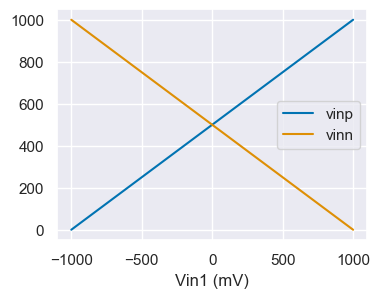

In [9]:
# show the unique values of the input signal
fig, ax = plt.subplots(figsize=(4, 3))
ax.plot(vin1 / mV, vinp / mV, label="vinp")
ax.plot(vin1 / mV, vinn / mV, label="vinn")
ax.set_xlabel("Vin1 (mV)")
ax.legend()

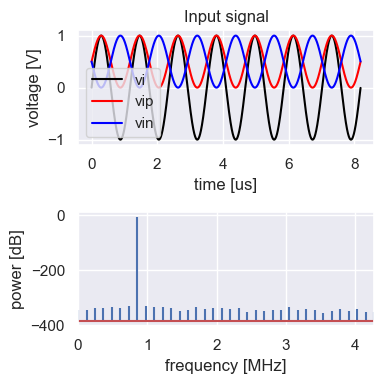

In [10]:
# observe the input signal in time and frequency
fig, ax = plt.subplots(2, 1, figsize=(4, 4))
ax[0].plot(tD / us, vin1t, label="vi", color="black")
ax[0].plot(tD / us, vint_p, label="vip", color="red")
ax[0].plot(tD / us, vint_n, label="vin", color="blue")
ax[0].legend()
ax[0].set_xlabel("time [us]")
ax[0].set_ylabel("voltage [V]")
ax[0].set_title("Input signal")
ax[0].grid(True)
ax[1].stem(
    fD[fD >= 0] / MHz,
    power_vinf_dB[fD >= 0],
    label="input signal in frequency",
    bottom=np.min(power_vinf_dB),
    linefmt="b-",
    markerfmt="none",
    basefmt="r-",
)
ax[1].grid(True)
ax[1].set_xlabel("frequency [MHz]")
ax[1].set_ylabel("power [dB]")
# close up on the frequency axis
ax[1].set_xlim([0, 5 * f1 / MHz])
plt.tight_layout()
plt.show()

## SAR ADC Conversion Phases

The `loop_unrolled_bottom_plate_sampling_monotonic_splitcap_sar_adc` function models the conversion in `nbits + 2` discrete phases:

1. **Bottom-plate sampling:** The input differential voltage is sampled at the bottom plates of the capacitor arrays while the top plates are held at VCM. The initial charge on each array is set by this phase.

2. **Bit conversion — MSB to second-to-last bit (for loop):** For each bit `k` from 0 to `nbits − 2`, the capacitor bottom plates are commuted between VREFP and VREFN according to all previous bit decisions. The new top-plate voltage is compared against VCM (plus the comparator offset) to decide the current bit.

3. **LSB conversion:** The unsplit LSB capacitor commutes in one array while the residue capacitor in the odd array remains pre-connected to VREFP. This is handled separately from the main loop because only one switch commutes per array.

4. **Residue voltage sampling (optional):** When `compute_residue=True`, the residue capacitor of the negative array is programmed asymmetrically to expose the residue voltage Vres = Vp − Vn at the top-plate nodes, making it available for the second stage.

## First Sub-ADC High-Level Model

In [11]:
def loop_unrolled_bottom_plate_sampling_monotonic_splitcap_sar_adc(
    vin,
    vrefp,
    vrefn,
    vdd,
    vss,
    nbits=6,
    cap_err_mean=0.0,
    cap_mismatch=0.05,
    comp_offset=0.0,
    compute_residue=True,
):
    """High-level circuit model of a Differential
    VCM-Based Loop Unrolled Bottom-Plate Sampling
    Successive Approximation Register (SAR) Analog-to-Digital Converter (ADC).

    Args:
        vin (_type_)    : Differential input voltage of the ADC.
        vrefp (_type_)  : Positive reference voltage of the ADC.
        vrefn (_type_)  : Negative reference voltage of the ADC.
        vdd (_type_)    : Positive supply voltage of the ADC.
        vss (_type_)    : Negative supply voltage of the ADC.
        nbits (int, optional): Output digital word resolution. Defaults to 6.
        cap_err_mean (float, optional): Mean value of the capacitor mismatch. Defaults to 0.0.
        cap_mismatch (float, optional): Standard deviation of the capacitance (Capacitor mismatch). Defaults to 0.05.
        comp_offset (float, optional): Standard deviation of the comparators' offsets. Defaults to 0.0.
        compute_residue (bool, optional): Flag to enable/disable the programming of the last (residue) capacitor.
            Programming the residue capacitor enables an additional conversion step,
            used to sample the residue voltage at the end of the conversion to enable pipelining.
            Defaults to True.

    Returns:
        dout_dec (_type_)   : Digital output of the ADC in decimal format.
        dout (_type_)       : Digital output of the ADC in binary format.
        charge_p (_type_)   : Charge at the positive array.
        charge_n (_type_)   : Charge at the negative array.
        vres (_type_)       : Residue voltage sampled at the end of the conversion.
        vp (_type_)         : Node voltage at the positive array in each conversion step.
        vn (_type_)         : Node voltage at the negative array in each conversion step.

    """
    vcm = np.mean([vdd, vss])
    vinp = (vin) / 2 + vcm
    vinn = -(vin) / 2 + vcm

    std_cap_err = cap_mismatch
    num_caps_array = nbits - 2
    num_unit_caps_array = 2**num_caps_array

    # positive array
    cap_err_even = normal(cap_err_mean, std_cap_err, num_unit_caps_array)
    unittary_caps = np.ones(len(cap_err_even)) * (1 + cap_err_even)
    pos_cap_even = np.array(
        [unittary_caps[-1]]
        + [
            np.sum(unittary_caps[2**b - 1 : 2 ** (b + 1) - 1])
            for b in range(num_caps_array)
        ]
    )
    cap_err_odd = normal(cap_err_mean, std_cap_err, num_unit_caps_array)
    unittary_caps = np.ones(len(cap_err_odd)) * (1 + cap_err_odd)
    pos_cap_odd = np.array(
        [unittary_caps[-1]]
        + [
            np.sum(unittary_caps[2**b - 1 : 2 ** (b + 1) - 1])
            for b in range(num_caps_array)
        ]
    )

    # negative array
    cap_err_even = normal(cap_err_mean, std_cap_err, num_unit_caps_array)
    unittary_caps = np.ones(len(cap_err_even)) * (1 + cap_err_even)
    neg_cap_even = np.array(
        [unittary_caps[-1]]
        + [
            np.sum(unittary_caps[2**b - 1 : 2 ** (b + 1) - 1])
            for b in range(num_caps_array)
        ]
    )
    cap_err_odd = normal(cap_err_mean, std_cap_err, 2 ** (nbits - 2))
    unittary_caps = np.ones(len(cap_err_odd)) * (1 + cap_err_odd)
    neg_cap_odd = np.array(
        [unittary_caps[-1]]
        + [
            np.sum(unittary_caps[2**b - 1 : 2 ** (b + 1) - 1])
            for b in range(num_caps_array)
        ]
    )

    # put heavier capacitors at the beginning of the array
    pos_cap_even = pos_cap_even[::-1]
    pos_cap_odd = pos_cap_odd[::-1]
    neg_cap_even = neg_cap_even[::-1]
    neg_cap_odd = neg_cap_odd[::-1]

    vcomps_err = normal(0, comp_offset, nbits)
    vcomps = vcomps_err

    # Each conversion has nbits + 2 steps:
    # a) bottom-plate sampling phase
    # b) one step per bit conversion
    # c) residue voltage sampling
    vp = np.zeros((nbits + 2, len(vinp)))
    vn = np.zeros((nbits + 2, len(vinn)))

    charge_p = np.zeros((len(vp), len(vinp)))
    charge_n = np.zeros((len(vn), len(vinn)))

    charge_vref = np.zeros((len(vp), len(vinp)))
    charge_vcm = np.zeros((len(vp), len(vinp)))

    pos_total_cap = np.sum(pos_cap_even) + np.sum(pos_cap_odd)
    neg_total_cap = np.sum(neg_cap_even) + np.sum(neg_cap_odd)

    # bottom-plate sampling phase
    vp[0, :] = vcm
    vn[0, :] = vcm
    charge_p[0, :] = (vp[0, :] - vinp) * pos_total_cap
    charge_n[0, :] = (vn[0, :] - vinn) * neg_total_cap
    charge_vcm[0, :] = vcm * (neg_total_cap + pos_total_cap)

    dout = np.zeros((nbits, len(vinp)))
    dout_neg = np.zeros((nbits, len(vinp)))

    # conversion steps: MSB to second-to-last bit
    for k in range(0, nbits - 1):
        cap_vrefp_pos = (
            np.sum(pos_cap_odd[k:])
            + dout[:-2, :].T @ pos_cap_even[:-1].reshape(-1, 1)
            + dout[:-2, :].T @ pos_cap_odd[:-1].reshape(-1, 1)
        )
        cap_vrefn_pos = (
            np.sum(pos_cap_even[k:])
            + dout_neg[:-2, :].T @ pos_cap_even[:-1].reshape(-1, 1)
            + dout_neg[:-2, :].T @ pos_cap_odd[:-1].reshape(-1, 1)
        )

        cap_vrefp_pos = cap_vrefp_pos.T
        cap_vrefn_pos = cap_vrefn_pos.T

        vp[k + 1, :] = (
            charge_p[k, :] + vrefp * cap_vrefp_pos + vrefn * cap_vrefn_pos
        ) / pos_total_cap
        charge_p[k + 1, :] = (vp[k + 1, :] - vrefp) * cap_vrefp_pos + (
            vp[k + 1, :] - vrefn
        ) * cap_vrefn_pos

        cap_vrefp_neg = (
            np.sum(neg_cap_odd[k:])
            + dout_neg[:-2, :].T @ neg_cap_even[:-1].reshape(-1, 1)
            + dout_neg[:-2, :].T @ neg_cap_odd[:-1].reshape(-1, 1)
        )
        cap_vrefn_neg = (
            np.sum(neg_cap_even[k:])
            + dout[:-2, :].T @ neg_cap_even[:-1].reshape(-1, 1)
            + dout[:-2, :].T @ neg_cap_odd[:-1].reshape(-1, 1)
        )

        cap_vrefp_neg = cap_vrefp_neg.T
        cap_vrefn_neg = cap_vrefn_neg.T

        vn[k + 1, :] = (
            charge_n[k, :] + vrefp * cap_vrefp_neg + vrefn * cap_vrefn_neg
        ) / neg_total_cap
        charge_n[k + 1, :] = (vn[k + 1, :] - vrefp) * cap_vrefp_neg + (
            vn[k + 1, :] - vrefn
        ) * cap_vrefn_neg

        dout[k, :] = vp[k + 1, :] - vn[k + 1, :] < vcomps[k]
        dout_neg[k, :] = 1 - dout[k, :]

        charge_vref[k + 1, :] = (vp[k + 1, :] - vrefp) * cap_vrefp_pos + (
            vn[k + 1, :] - vrefp
        ) * cap_vrefp_neg

    # LSB conversion: only one capacitor commutes per array
    k += 1
    cap_vrefp_pos = (
        pos_cap_odd[-1]
        + dout[:-1, :].T @ pos_cap_even.reshape(-1, 1)
        + dout[:-2, :].T @ pos_cap_odd[:-1].reshape(-1, 1)
    )
    cap_vrefn_pos = dout_neg[:-1, :].T @ pos_cap_even.reshape(-1, 1) + dout_neg[
        :-2, :
    ].T @ pos_cap_odd[:-1].reshape(-1, 1)

    cap_vrefp_pos = cap_vrefp_pos.T
    cap_vrefn_pos = cap_vrefn_pos.T

    vp[k + 1, :] = (
        charge_p[k, :] + vrefp * cap_vrefp_pos + vrefn * cap_vrefn_pos
    ) / pos_total_cap
    charge_p[k + 1, :] = (vp[k + 1, :] - vrefp) * cap_vrefp_pos + (
        vp[k + 1, :] - vrefn
    ) * cap_vrefn_pos

    cap_vrefp_neg = (
        neg_cap_odd[-1]
        + dout_neg[:-1, :].T @ neg_cap_even.reshape(-1, 1)
        + dout_neg[:-2, :].T @ neg_cap_odd[:-1].reshape(-1, 1)
    )
    cap_vrefn_neg = dout[:-1, :].T @ neg_cap_even.reshape(-1, 1) + dout[
        :-2, :
    ].T @ neg_cap_odd[:-1].reshape(-1, 1)

    cap_vrefp_neg = cap_vrefp_neg.T
    cap_vrefn_neg = cap_vrefn_neg.T

    vn[k + 1, :] = (
        charge_n[k, :] + vrefp * cap_vrefp_neg + vrefn * cap_vrefn_neg
    ) / neg_total_cap
    charge_n[k + 1, :] = (vn[k + 1, :] - vrefp) * cap_vrefp_neg + (
        vn[k + 1, :] - vrefn
    ) * cap_vrefn_neg

    dout[k, :] = vp[k + 1, :] - vn[k + 1, :] < vcomps[k]
    dout_neg[k, :] = 1 - dout[k, :]

    charge_vref[k + 1, :] = (vp[k + 1, :] - vrefp) * cap_vrefp_pos + (
        vn[k + 1, :] - vrefp
    ) * cap_vrefp_neg

    k += 1
    vp[k + 1, :] = vp[k, :]
    vn[k + 1, :] = vn[k, :]
    charge_p[k + 1, :] = charge_p[k, :]
    charge_n[k + 1, :] = charge_n[k, :]
    if compute_residue:
        # Residue voltage sampling: program the residue capacitor asymmetrically
        # so that vres = vp - vn is obtained correctly, enabling pipelining.
        cap_vrefp_neg = (
            (dout_neg[-1, :] * neg_cap_odd[-1]).reshape((-1, 1))
            + dout_neg[:-1, :].T @ neg_cap_even.reshape(-1, 1)
            + dout_neg[:-2, :].T @ neg_cap_odd[:-1].reshape(-1, 1)
        )
        cap_vrefn_neg = (
            (dout[-1, :] * neg_cap_odd[-1]).reshape((-1, 1))
            + dout[:-1, :].T @ neg_cap_even.reshape(-1, 1)
            + dout[:-2, :].T @ neg_cap_odd[:-1].reshape(-1, 1)
        )

        cap_vrefp_neg = cap_vrefp_neg.T
        cap_vrefn_neg = cap_vrefn_neg.T

        vn[k + 1, :] = (
            charge_n[k, :] + vrefp * cap_vrefp_neg + vrefn * cap_vrefn_neg
        ) / neg_total_cap
        charge_n[k + 1, :] = (vn[k + 1, :] - vrefp) * cap_vrefp_neg + (
            vn[k + 1, :] - vrefn
        ) * cap_vrefn_neg

        charge_vref[k + 1, :] = (vp[k + 1, :] - vrefp) * cap_vrefp_pos + (
            vn[k + 1, :] - vrefp
        ) * cap_vrefp_neg

    vres = vp[-1, :] - vn[-1, :]
    dout_dec = bin2dec(dout.T, width=nbits, reverse=False)

    charge_vref = np.diff(charge_vref, axis=0)
    charge_vcm = np.diff(charge_vcm, axis=0)

    return dout_dec, dout.T, charge_vref, charge_vcm, vres, vp, vn

## Residue Amplifier Transfer Function

The residue amplifier amplifies the residue voltage Vres from the first sub-ADC and feeds it into the second sub-ADC. The gain is set to `-(2^(Nbits_first - 1) / second_adc_gain)` (negative, because the first-stage residue is inverted). A settling factor models incomplete settling: `Vout = G * Vin * (1 - exp(-SF))`, where SF = Ta/τ.

In [12]:
def residue_amplifier(
    vin,
    vdd,
    vss,
    gain=8.0,
    offset=0.0,
    settling_factor=5,
):
    """High-level circuit model of a residue amplifier.
    This model includes a settling factor to account for
    the settling time of the amplifier. The settling factor
    is SF = Ta/Tau, where Ta is the available amplification time
    (which usually corresponds to half of the period of the sampling clock)
    of the amplifier and Tau is the time constant of the amplifier,
    corresponding to the inverse of the amplifier's bandwidth.
    Args:
        vin (ndarray)    : Input voltage of the amplifier.
        vdd (ndarray)    : Positive supply voltage of the amplifier.
        vss (ndarray)    : Negative supply voltage of the amplifier.
        gain (float, optional): Gain of the amplifier. Defaults to 8.0.
        offset (float, optional): Offset of the amplifier. Defaults to 0.0.
        settling_factor (int, optional): Settling factor of the amplifier. Defaults to 5.

    Returns:
        vout (ndarray)   : Output voltage of the amplifier.
    """
    vout = gain * vin * (1 - np.exp(-settling_factor)) + offset
    vout[vout > vdd] = vdd
    vout[vout < vss] = vss
    return vout

## Monte Carlo Simulation Control Parameters

The following control variables govern all Monte Carlo simulations. Capacitor mismatch is modelled as a Gaussian distribution with zero mean and a standard deviation of 1% (`CAP_MISMATCH_STD = 0.01`). Comparator offsets are swept from 0 to `MAX_COMP_OFST` across `NUM_COMP_OFSTS` steps.

In [13]:
# CONTROL VARIABLES FOR ALL SIMULATIONS
NUM_CIRCUITS = 1000  # number of circuits in monte carlo simulation
CAP_MISMATCH_MEAN = 0.0
CAP_MISMATCH_STD = 0.01  # 1% Capacitance mismatch
NUM_COMP_OFSTS = 5
MAX_COMP_OFST = 5 * mV

## First Sub-ADC Monte Carlo Analysis

The first sub-ADC (6-bit) is evaluated by running `NUM_CIRCUITS` independent Monte Carlo trials for each comparator offset standard deviation value. For each trial, the DNL and INL are computed from the measured transition voltages of the transfer function, and the achievable ENOB is derived from the peak INL.

In [14]:
first_sub_adc_avg_lin = []

comp_offsets = np.linspace(0, MAX_COMP_OFST, NUM_COMP_OFSTS)
cap_err_mean = CAP_MISMATCH_MEAN
cap_mismatch = CAP_MISMATCH_STD

for comp_offset in comp_offsets:
    first_sub_adc_lins = []
    for _ in range(NUM_CIRCUITS):
        (
            dout_dec_first,
            _,
            charge_vref_first,
            charge_vcm_first,
            vres_first,
            vp_first,
            vn_first,
        ) = loop_unrolled_bottom_plate_sampling_monotonic_splitcap_sar_adc(
            vin=vin1,
            vrefp=vrefp_first,
            vrefn=vrefn_first,
            vdd=vdd,
            vss=vss,
            nbits=Nbits_first,
            cap_err_mean=cap_err_mean,
            cap_mismatch=cap_mismatch,
            comp_offset=comp_offset,
            compute_residue=True,
        )
        # get the transition voltages of the first sub ADC
        dout_first = dout_dec_first[np.where(np.diff(dout_dec_first) > 0)]
        vtrans_first = vin1[np.where(np.diff(dout_dec_first) > 0)]

        vlsb_measured_first = (vtrans_first[-1] - vtrans_first[0]) / (
            2**Nbits_first - 2
        )
        dnl_first = np.diff(vtrans_first) / vlsb_measured_first - 1
        inl_first = np.array([0] + np.cumsum(dnl_first).tolist())
        adc_linearity = Nbits_first - np.log2(np.max(inl_first) - np.min(inl_first))
        first_sub_adc_lins.append(adc_linearity)

    first_sub_adc_avg_lin.append(np.mean(first_sub_adc_lins))

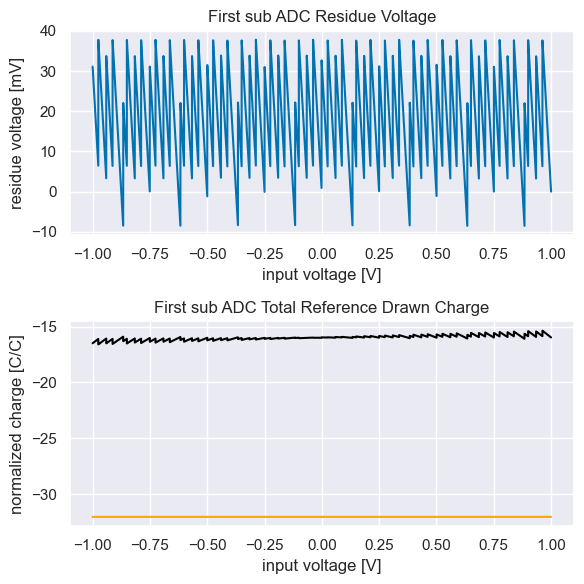

In [15]:
# residue voltage of the first sub SAR-ADC vs. input voltage
fig, ax = plt.subplots(2, 1, figsize=(6, 6))
ax[0].plot(vin1, vres_first / mV)
ax[0].set_xlabel("input voltage [V]")
ax[0].set_ylabel("residue voltage [mV]")
ax[0].set_title("First sub ADC Residue Voltage")
ax[0].grid(True)
ax[1].plot(vin1, np.sum(charge_vref_first, axis=0), label=r"$Q_{VREF}$", color="black")
ax[1].plot(vin1, np.sum(charge_vcm_first, axis=0), label=r"$Q_{VCM}$", color="orange")
ax[1].set_xlabel("input voltage [V]")
ax[1].set_ylabel("normalized charge [C/C]")
ax[1].set_title("First sub ADC Total Reference Drawn Charge")
ax[1].grid(True)
plt.tight_layout()

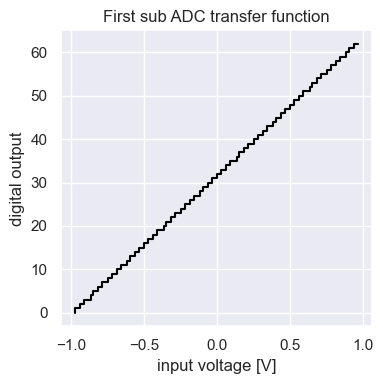

In [16]:
fig, ax = plt.subplots(figsize=(4, 4))
ax.step(
    vtrans_first,
    dout_first,
    label="first sub ADC transfer function",
    color="black",
    where="pre",
)
ax.set_xlabel("input voltage [V]")
ax.set_ylabel("digital output")
ax.set_title("First sub ADC transfer function")
ax.grid(True)
plt.tight_layout()

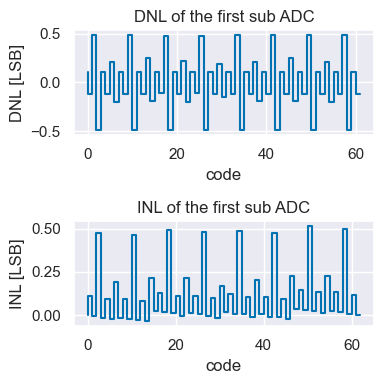

In [17]:
# plot the INL and DNL of the first sub ADC
fig, ax = plt.subplots(2, 1, figsize=(4, 4))
ax[0].step(dout_first[:-1], dnl_first, label="DNL")
ax[0].set_xlabel("code")
ax[0].set_ylabel("DNL [LSB]")
ax[0].set_title("DNL of the first sub ADC")
ax[0].grid(True)
ax[1].step(dout_first, inl_first, label="INL")
ax[1].set_xlabel("code")
ax[1].set_ylabel("INL [LSB]")
ax[1].set_title("INL of the first sub ADC")
ax[1].grid(True)
plt.tight_layout()

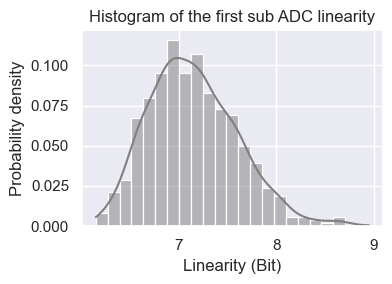

In [18]:
# plot the linearity histogram of the first sub ADC
fig, ax = plt.subplots(figsize=(4, 3))
sns.histplot(
    first_sub_adc_lins,
    ax=ax,
    kde=True,
    stat="probability",
    color="gray",
    label="first sub ADC linearity",
)
ax.set_xlabel("Linearity (Bit)")
ax.set_ylabel("Probability density")
ax.set_title("Histogram of the first sub ADC linearity")
plt.tight_layout()

/var/folders/58/9x4h23m57hl3nj4g9kjnldhw0000gn/T/ipykernel_33619/1566581067.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(np.round(comp_offsets / mV, 2), rotation=45)


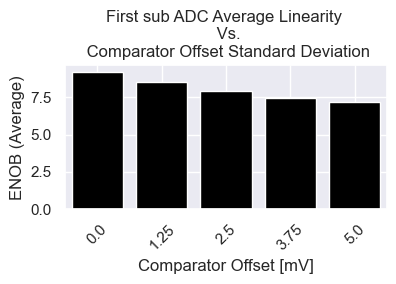

In [19]:
# observe the average linearity of the first sub ADC
# against comparator offset
fig, ax = plt.subplots(figsize=(4, 3))
sns.barplot(x=comp_offsets / mV, y=first_sub_adc_avg_lin, color="black", ax=ax)
ax.set_xlabel("Comparator Offset [mV]")
ax.set_ylabel("ENOB (Average)")
ax.set_title(
    "First sub ADC Average Linearity \n Vs.\n Comparator Offset Standard Deviation"
)
ax.set_xticklabels(np.round(comp_offsets / mV, 2), rotation=45)
ax.grid(True)
plt.tight_layout()

## Second Sub-ADC Monte Carlo Analysis

The second sub-ADC (7-bit, operating on the residue-amplified output of the first stage) is evaluated under the same Monte Carlo conditions as the first sub-ADC. Its input range is scaled by `1/second_adc_gain` relative to the first stage.

In [20]:
second_sub_adc_avg_lins = []

comp_offsets = np.linspace(0, MAX_COMP_OFST, NUM_COMP_OFSTS)
cap_err_mean = CAP_MISMATCH_MEAN
cap_mismatch = CAP_MISMATCH_STD

vin2 = vin1 / second_adc_gain

for comp_offset in comp_offsets:
    second_sub_adc_lins = []
    for _ in range(NUM_CIRCUITS):
        (
            dout_dec_second,
            _,
            charge_vref_second,
            charge_vcm_second,
            vres_second,
            vp_second,
            vn_second,
        ) = loop_unrolled_bottom_plate_sampling_monotonic_splitcap_sar_adc(
            vin=vin2,
            vrefp=vrefp_second,
            vrefn=vrefn_second,
            vdd=vdd,
            vss=vss,
            nbits=Nbits_second,
            cap_err_mean=cap_err_mean,
            cap_mismatch=cap_mismatch,
            comp_offset=comp_offset,
            compute_residue=True,
        )
        # get the transition voltages of the second sub ADC
        dout_second = dout_dec_second[np.where(np.diff(dout_dec_second) > 0)]
        vtrans_second = vin2[np.where(np.diff(dout_dec_second) > 0)]

        vlsb_measured_second = (vtrans_second[-1] - vtrans_second[0]) / (
            2**Nbits_second - 2
        )
        dnl_second = np.diff(vtrans_second) / vlsb_measured_second - 1
        inl_second = np.array([0] + np.cumsum(dnl_second).tolist())
        adc_linearity_second = Nbits_second - np.log2(
            np.max(inl_second) - np.min(inl_second)
        )
        second_sub_adc_lins.append(adc_linearity_second)

    second_sub_adc_avg_lins.append(np.mean(second_sub_adc_lins))

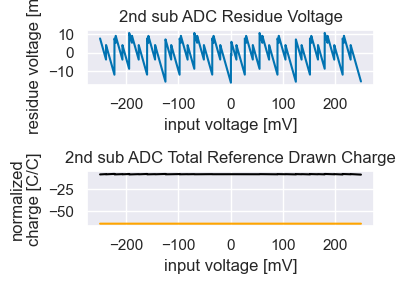

In [21]:
# residue voltage of the second sub SAR-ADC vs. input voltage
fig, ax = plt.subplots(2, 1, figsize=(4, 3))
ax[0].plot(vin2 / mV, vres_second / mV)
ax[0].set_xlabel("input voltage [mV]")
ax[0].set_ylabel("residue voltage [mV]")
ax[0].set_title("2nd sub ADC Residue Voltage")
ax[0].grid(True)
ax[1].plot(
    vin2 / mV, np.sum(charge_vref_second, axis=0), label=r"$Q_{VREF}$", color="black"
)
ax[1].plot(
    vin2 / mV, np.sum(charge_vcm_second, axis=0), label=r"$Q_{VCM}$", color="orange"
)
ax[1].set_xlabel("input voltage [mV]")
ax[1].set_ylabel("normalized\ncharge [C/C]")
ax[1].set_title("2nd sub ADC Total Reference Drawn Charge")
ax[1].grid(True)
plt.tight_layout()

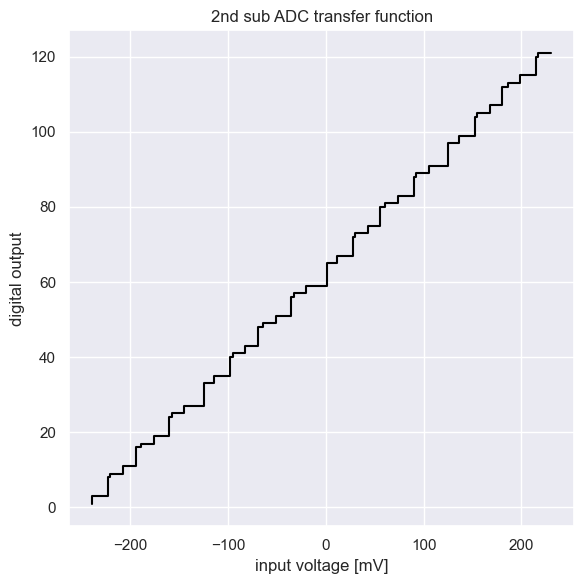

In [22]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.step(
    vtrans_second / mV,
    dout_second,
    label="2nd sub ADC transfer function",
    color="black",
    where="pre",
)
ax.set_xlabel("input voltage [mV]")
ax.set_ylabel("digital output")
ax.set_title("2nd sub ADC transfer function")
ax.grid(True)
plt.tight_layout()

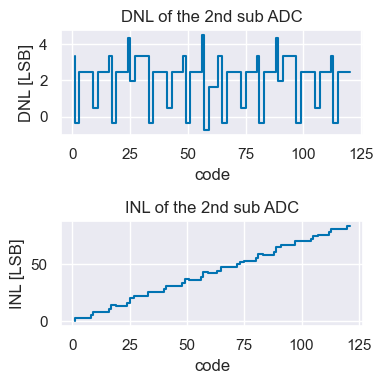

In [23]:
fig, ax = plt.subplots(2, 1, figsize=(4, 4))
ax[0].step(dout_second[:-1], dnl_second, label="DNL")
ax[0].set_xlabel("code")
ax[0].set_ylabel("DNL [LSB]")
ax[0].set_title("DNL of the 2nd sub ADC")
ax[0].grid(True)
ax[1].step(dout_second, inl_second, label="INL")
ax[1].set_xlabel("code")
ax[1].set_ylabel("INL [LSB]")
ax[1].set_title("INL of the 2nd sub ADC")
ax[1].grid(True)
plt.tight_layout()

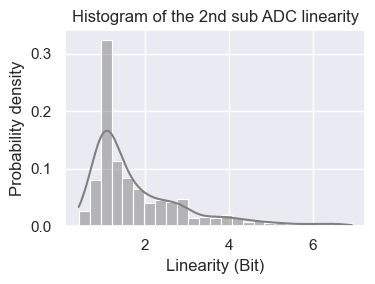

In [24]:
fig, ax = plt.subplots(figsize=(4, 3))
sns.histplot(
    second_sub_adc_lins,
    ax=ax,
    kde=True,
    stat="probability",
    color="gray",
    label="2nd sub ADC linearity",
)
ax.set_xlabel("Linearity (Bit)")
ax.set_ylabel("Probability density")
ax.set_title("Histogram of the 2nd sub ADC linearity")
plt.tight_layout()

/var/folders/58/9x4h23m57hl3nj4g9kjnldhw0000gn/T/ipykernel_33619/3165211460.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(np.round(comp_offsets / mV, 2), rotation=45)


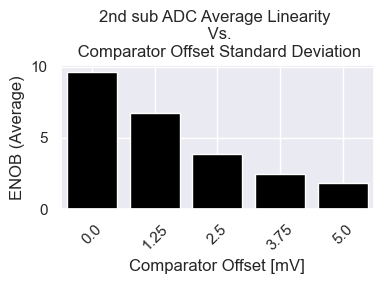

In [25]:
fig, ax = plt.subplots(figsize=(4, 3))
sns.barplot(x=comp_offsets / mV, y=second_sub_adc_avg_lins, color="black", ax=ax)
ax.set_xlabel("Comparator Offset [mV]")
ax.set_ylabel("ENOB (Average)")
ax.set_title(
    "2nd sub ADC Average Linearity \n Vs.\n Comparator Offset Standard Deviation"
)
ax.set_xticklabels(np.round(comp_offsets / mV, 2), rotation=45)
ax.grid(True)
plt.tight_layout()

## Full 2-Step ADC Monte Carlo Analysis

The complete 2-step pipeline ADC is now simulated via Monte Carlo to evaluate linearity as a function of residue amplifier gain error (GER). The gain error sweeps from −3% to +3%, and for each gain error value the linearity (ENOB) is averaged across all Monte Carlo trials.

In [26]:
adc_avg_lins = []

comp_offsets = np.linspace(0, MAX_COMP_OFST, 1)
cap_err_mean = CAP_MISMATCH_MEAN
cap_mismatch = CAP_MISMATCH_STD

Num_gers = 11
max_ger = 0.03
ra_gers = np.linspace(-max_ger, max_ger, Num_gers)

for ger in ra_gers:
    for comp_offset in comp_offsets:
        adc_lins = []

        for _ in range(NUM_CIRCUITS):
            """ FIRST STAGE """
            (
                dout_dec_first,
                dout_bin_first,
                charge_vref_first,
                charge_vcm_first,
                vres_first,
                vp_first,
                vn_first,
            ) = loop_unrolled_bottom_plate_sampling_monotonic_splitcap_sar_adc(
                vin=vin1,
                vrefp=vrefp_first,
                vrefn=vrefn_first,
                vdd=vdd,
                vss=vss,
                nbits=Nbits_first,
                cap_err_mean=cap_err_mean,
                cap_mismatch=cap_mismatch,
                comp_offset=comp_offset,
                compute_residue=True,
            )

            """ RESIDUE AMPLIFIER """
            # Gain is inverted because the residue voltage is inverted
            # at the output of the first quantizer stage
            ra_gain = -(1 + ger) * (2 ** (Nbits_first - 1) / second_adc_gain)
            vout_ra = residue_amplifier(
                vres_first - 0.0 * np.mean(vres_first),
                vdd,
                -vdd,
                gain=ra_gain,
                offset=0.0,
                settling_factor=100,
            )

            """ SECOND STAGE """
            (
                dout_dec_second,
                dout_bin_second,
                _,
                _,
                vres_second,
                vp_second,
                vn_second,
            ) = loop_unrolled_bottom_plate_sampling_monotonic_splitcap_sar_adc(
                vin=vout_ra,
                vrefp=vrefp_second,
                vrefn=vrefn_second,
                vdd=vdd,
                vss=vss,
                nbits=Nbits_second,
                cap_err_mean=cap_err_mean,
                cap_mismatch=cap_mismatch,
                comp_offset=comp_offset,
                compute_residue=True,
            )

            dout_dec = dout_dec_first * 2 ** (Nbits_second - 1) + (
                dout_dec_second - 2 ** (Nbits_second - 2)
            )

            dout = dout_dec[np.where(np.diff(dout_dec) > 0)]
            vtrans = vin1[np.where(np.diff(dout_dec) > 0)]

            vlsb_measured = (vtrans[-1] - vtrans[0]) / (
                2 ** (Nbits_first + Nbits_second - 1) - 2
            )
            dnl = np.diff(vtrans) / vlsb_measured - 1
            inl = np.array([0] + np.cumsum(dnl).tolist())
            adc_linearity = (
                Nbits_first - 1 + Nbits_second - np.log2(np.max(inl) - np.min(inl))
            )
            adc_lins.append(adc_linearity)

        adc_avg_lins.append(np.mean(adc_lins))

Total Amp RA:  273.2263943094236  mV
RA Gain:  -8.24  V/V


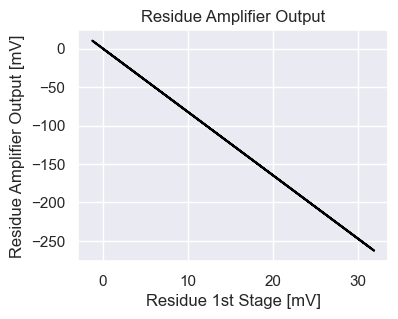

In [27]:
# observe vout of the residue amplifier versus vres 1st stage
fig, ax = plt.subplots(1, 1, figsize=(4, 3))
ax.plot(vres_first / mV, vout_ra / mV, label="vout_ra", color="black")
ax.set_xlabel("Residue 1st Stage [mV]")
ax.set_ylabel("Residue Amplifier Output [mV]")
ax.set_title("Residue Amplifier Output")
print("Total Amp RA: ", (np.max(vout_ra) - np.min(vout_ra)) / mV, " mV")
print("RA Gain: ", ra_gain, " V/V")

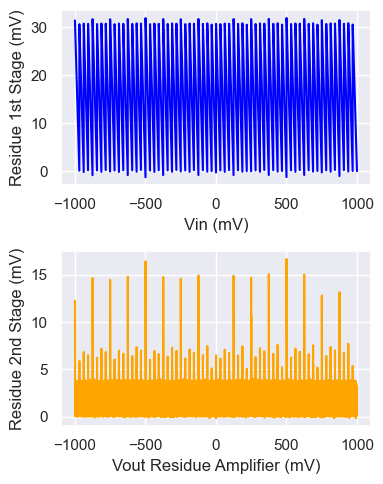

In [28]:
# plot the voltage input of the first stage vs the voltage output
fig, ax = plt.subplots(2, 1, figsize=(4, 5))
ax[0].plot(vin1 / mV, vres_first / mV, color="blue")
ax[1].plot(vin1 / mV, vres_second / mV, color="orange")
ax[0].set_xlabel("Vin (mV)")
ax[0].set_ylabel("Residue 1st Stage (mV)")
ax[1].set_xlabel("Vout Residue Amplifier (mV)")
ax[1].set_ylabel("Residue 2nd Stage (mV)")
ax[0].grid(True)
ax[1].grid(True)
fig.tight_layout()

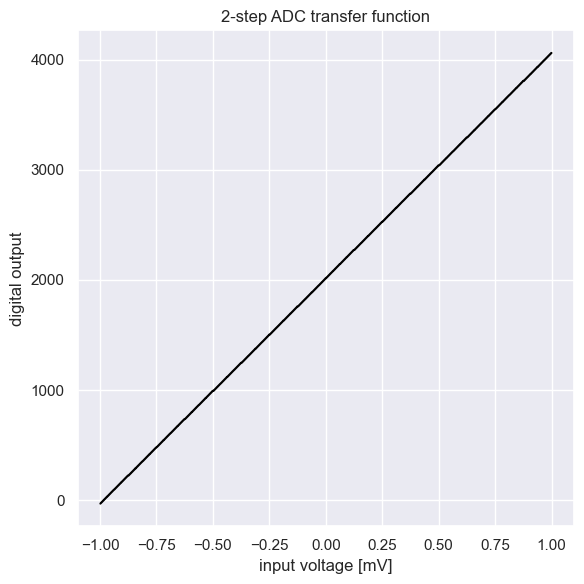

In [29]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.step(
    vtrans,
    dout,
    label="2-step ADC transfer function",
    color="black",
    where="pre",
)
ax.set_xlabel("input voltage [mV]")
ax.set_ylabel("digital output")
ax.set_title("2-step ADC transfer function")
ax.grid(True)
plt.tight_layout()

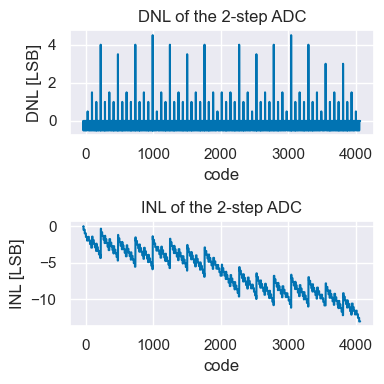

In [30]:
fig, ax = plt.subplots(2, 1, figsize=(4, 4))
ax[0].step(dout[:-1], dnl, label="DNL")
ax[0].set_xlabel("code")
ax[0].set_ylabel("DNL [LSB]")
ax[0].set_title("DNL of the 2-step ADC")
ax[0].grid(True)
ax[1].step(dout, inl, label="INL")
ax[1].set_xlabel("code")
ax[1].set_ylabel("INL [LSB]")
ax[1].set_title("INL of the 2-step ADC")
ax[1].grid(True)
plt.tight_layout()

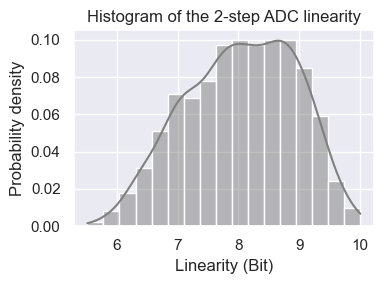

In [31]:
fig, ax = plt.subplots(figsize=(4, 3))
sns.histplot(
    adc_lins,
    ax=ax,
    kde=True,
    stat="probability",
    color="gray",
    label="2-step ADC linearity",
)
ax.set_xlabel("Linearity (Bit)")
ax.set_ylabel("Probability density")
ax.set_title("Histogram of the 2-step ADC linearity")
plt.tight_layout()

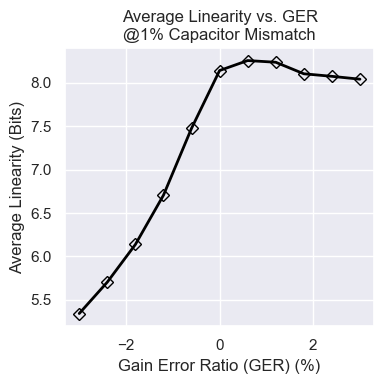

In [32]:
# observe the linearity against GER
fig, ax = plt.subplots(1, 1, figsize=(4, 4))
ax.plot(ra_gers * 100, adc_avg_lins, color="black", lw=2, marker="D", mfc="None")
ax.set_xlabel("Gain Error Ratio (GER) (%)")
ax.set_ylabel("Average Linearity (Bits)")
ax.set_title("Average Linearity vs. GER\n@1% Capacitor Mismatch")
ax.grid(True)
fig.tight_layout()

## Full 2-Stage Pipeline ADC — Spectral Analysis

The full 2-stage pipeline ADC is now simulated on a sinusoidal input to evaluate spectral performance. The output digital code is reconstructed by combining the first and second sub-ADC outputs, then passed through the `FFTEngine` to compute SNR, SNDR, ENOB, SFDR, and THD.

In [33]:
cap_err_mean = CAP_MISMATCH_MEAN
cap_mismatch = CAP_MISMATCH_STD

""" FIRST STAGE """
(dout_dec_first_t, _, _, _, vres_first_t, *_) = (
    loop_unrolled_bottom_plate_sampling_monotonic_splitcap_sar_adc(
        vin=vin1t,
        vrefp=vrefp_first,
        vrefn=vrefn_first,
        vdd=vdd,
        vss=vss,
        nbits=Nbits_first,
        cap_err_mean=cap_err_mean,
        cap_mismatch=cap_mismatch,
        comp_offset=comp_offset,
        compute_residue=True,
    )
)

""" RESIDUE AMPLIFIER """
# Gain is inverted because the residue voltage is inverted
# at the output of the first quantizer stage
ra_gain = -(1 + ger) * (2 ** (Nbits_first - 1) / second_adc_gain)
vout_ra_t = residue_amplifier(
    vres_first_t,
    vdd,
    -vdd,
    gain=ra_gain,
    offset=0.0,
    settling_factor=100,
)

""" SECOND STAGE """
(dout_dec_second_t, *_) = (
    loop_unrolled_bottom_plate_sampling_monotonic_splitcap_sar_adc(
        vin=vout_ra_t,
        vrefp=vrefp_second,
        vrefn=vrefn_second,
        vdd=vdd,
        vss=vss,
        nbits=Nbits_second,
        cap_err_mean=cap_err_mean,
        cap_mismatch=cap_mismatch,
        comp_offset=comp_offset,
        compute_residue=True,
    )
)

dout_dec_t = dout_dec_first_t * 2 ** (Nbits_second - 1) + (
    dout_dec_second_t - 2 ** (Nbits_second - 2)
)

# center the output around 0 and normalize
dout_dec_t = (dout_dec_t - 2 ** (Nbits_first + Nbits_second - 2)) / (
    2 ** (Nbits_first + Nbits_second - 1)
)

In [34]:
NUM_HARMONICS = 9
NUM_SIGNAL_BINS = 1

ffte = FFTEngine(dout_dec_t, time=tD)
*_, dout_p_f = ffte.fft(Np, fs=Fs, window="rectangular")

/Users/gfdasdias/Documents/Personal/signal-converters-notebooks/practical_classes/fft.py:108: UserWarning: fs - sampling frequency will be ignored since a time axis is provided.
  warn(


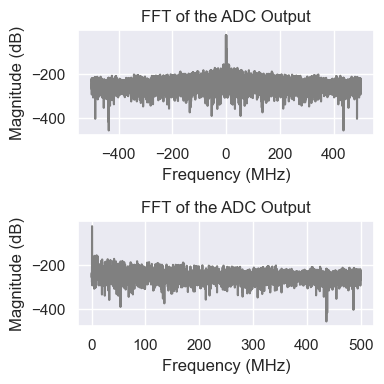

In [35]:
# plot the FFT of the output
fig, ax = plt.subplots(2, 1, figsize=(4, 4))
ax[0].plot(ffte.ff / MHz, 20 * np.log10(np.abs(dout_p_f)), color="gray")
ax[0].set_xlabel("Frequency (MHz)")
ax[0].set_ylabel("Magnitude (dB)")
ax[0].set_title("FFT of the ADC Output")
ax[0].grid(True)
ax[1].plot(
    ffte.ff[ffte.ff > 1] / MHz,
    20 * np.log10(np.abs(dout_p_f[ffte.ff > 1])),
    color="gray",
)
ax[1].set_xlabel("Frequency (MHz)")
ax[1].set_ylabel("Magnitude (dB)")
ax[1].set_title("FFT of the ADC Output")
ax[1].grid(True)
fig.tight_layout()

In [36]:
spectral_analysis = ffte.spectral_analysis(
    span=NUM_SIGNAL_BINS, harmonics=NUM_HARMONICS
)

print("Spectral Analysis:")
print("    SNDR : {:.2f} dB".format(spectral_analysis["sndr"]))
print("    ENOB : {:.2f} bits".format(spectral_analysis["enob"]))
print("    SFDR : {:.2f} dB".format(spectral_analysis["sfdr"]))
print("    THD  : {:.2f} dB".format(spectral_analysis["thd"]))
print("    SNR  : {:.2f} dB".format(spectral_analysis["snr"]))

Spectral Analysis:
    SNDR : 58.48 dB
    ENOB : 9.42 bits
    SFDR : 65.72 dB
    THD  : 63.34 dB
    SNR  : 60.20 dB
